In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

In [2]:
#load data sets
df = pd.read_excel("C:\\Users\\gagan\\Downloads\\EastWestAirlines.xlsx", sheet_name="data")
df.head()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,1,28143,0,1,1,1,174,1,0,0,7000,0
1,2,19244,0,1,1,1,215,2,0,0,6968,0
2,3,41354,0,1,1,1,4123,4,0,0,7034,0
3,4,14776,0,1,1,1,500,1,0,0,6952,0
4,5,97752,0,4,1,1,43300,26,2077,4,6935,1


In [3]:
#data transformation
print(df.shape)
print(df.info())
print(df.isnull().sum())

(3999, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3999 entries, 0 to 3998
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   ID#                3999 non-null   int64
 1   Balance            3999 non-null   int64
 2   Qual_miles         3999 non-null   int64
 3   cc1_miles          3999 non-null   int64
 4   cc2_miles          3999 non-null   int64
 5   cc3_miles          3999 non-null   int64
 6   Bonus_miles        3999 non-null   int64
 7   Bonus_trans        3999 non-null   int64
 8   Flight_miles_12mo  3999 non-null   int64
 9   Flight_trans_12    3999 non-null   int64
 10  Days_since_enroll  3999 non-null   int64
 11  Award?             3999 non-null   int64
dtypes: int64(12)
memory usage: 375.0 KB
None
ID#                  0
Balance              0
Qual_miles           0
cc1_miles            0
cc2_miles            0
cc3_miles            0
Bonus_miles          0
Bonus_trans          0
Flight_m

In [4]:
#statistical summary
df.describe()

,ID#,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
count,3999.000000,3.999000e+03,3999.000000,3999.000000,3999.000000,3999.000000,3999.000000,3999.00000,3999.000000,3999.000000,3999.00000,3999.000000
mean,2014.819455,7.360133e+04,144.114529,2.059515,1.014504,1.012253,17144.846212,11.60190,460.055764,1.373593,4118.55939,0.370343
std,1160.764358,1.007757e+05,773.663804,1.376919,0.147650,0.195241,24150.967826,9.60381,1400.209171,3.793172,2065.13454,0.482957
min,1.000000,0.000000e+00,0.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,2.00000,0.000000
25%,1010.500000,1.852750e+04,0.000000,1.000000,1.000000,1.000000,1250.000000,3.00000,0.000000,0.000000,2330.00000,0.000000
50%,2016.000000,4.309700e+04,0.000000,1.000000,1.000000,1.000000,7171.000000,12.00000,0.000000,0.000000,4096.00000,0.000000
75%,3020.500000,9.240400e+04,0.000000,3.000000,1.000000,1.000000,23800.500000,17.00000,311.000000,1.000000,5790.50000,1.000000
max,4021.000000,1.704838e+06,11148.000000,5.000000,3.000000,5.000000,263685.000000,86.00000,30817.000000,53.000000,8296.00000,1.000000


In [5]:
#remove id column
df1 = df.drop("ID#", axis=1)
df1.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,28143,0,1,1,1,174,1,0,0,7000,0
1,19244,0,1,1,1,215,2,0,0,6968,0
2,41354,0,1,1,1,4123,4,0,0,7034,0
3,14776,0,1,1,1,500,1,0,0,6952,0
4,97752,0,4,1,1,43300,26,2077,4,6935,1


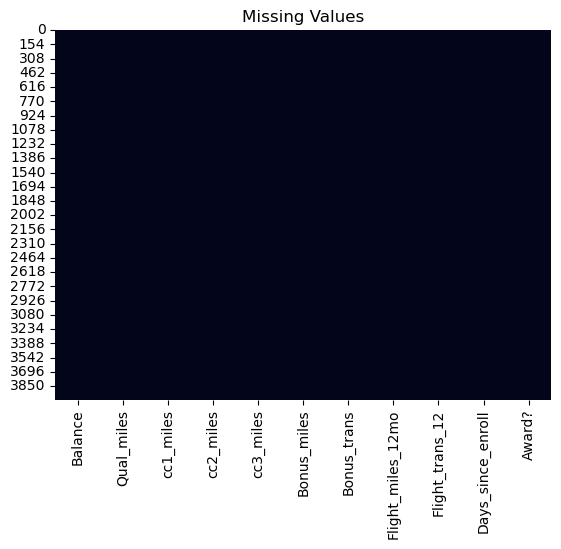

In [6]:
#missing value check
sns.heatmap(df1.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [7]:
#outlier removal
Q1 = df1.quantile(0.25)
Q3 = df1.quantile(0.75)

IQR = Q3 - Q1

df1 = df1[
    ~((df1 < (Q1 - 1.5 * IQR)) |
      (df1 > (Q3 + 1.5 * IQR))).any(axis=1)
]

print(df1.shape)

(2875, 11)


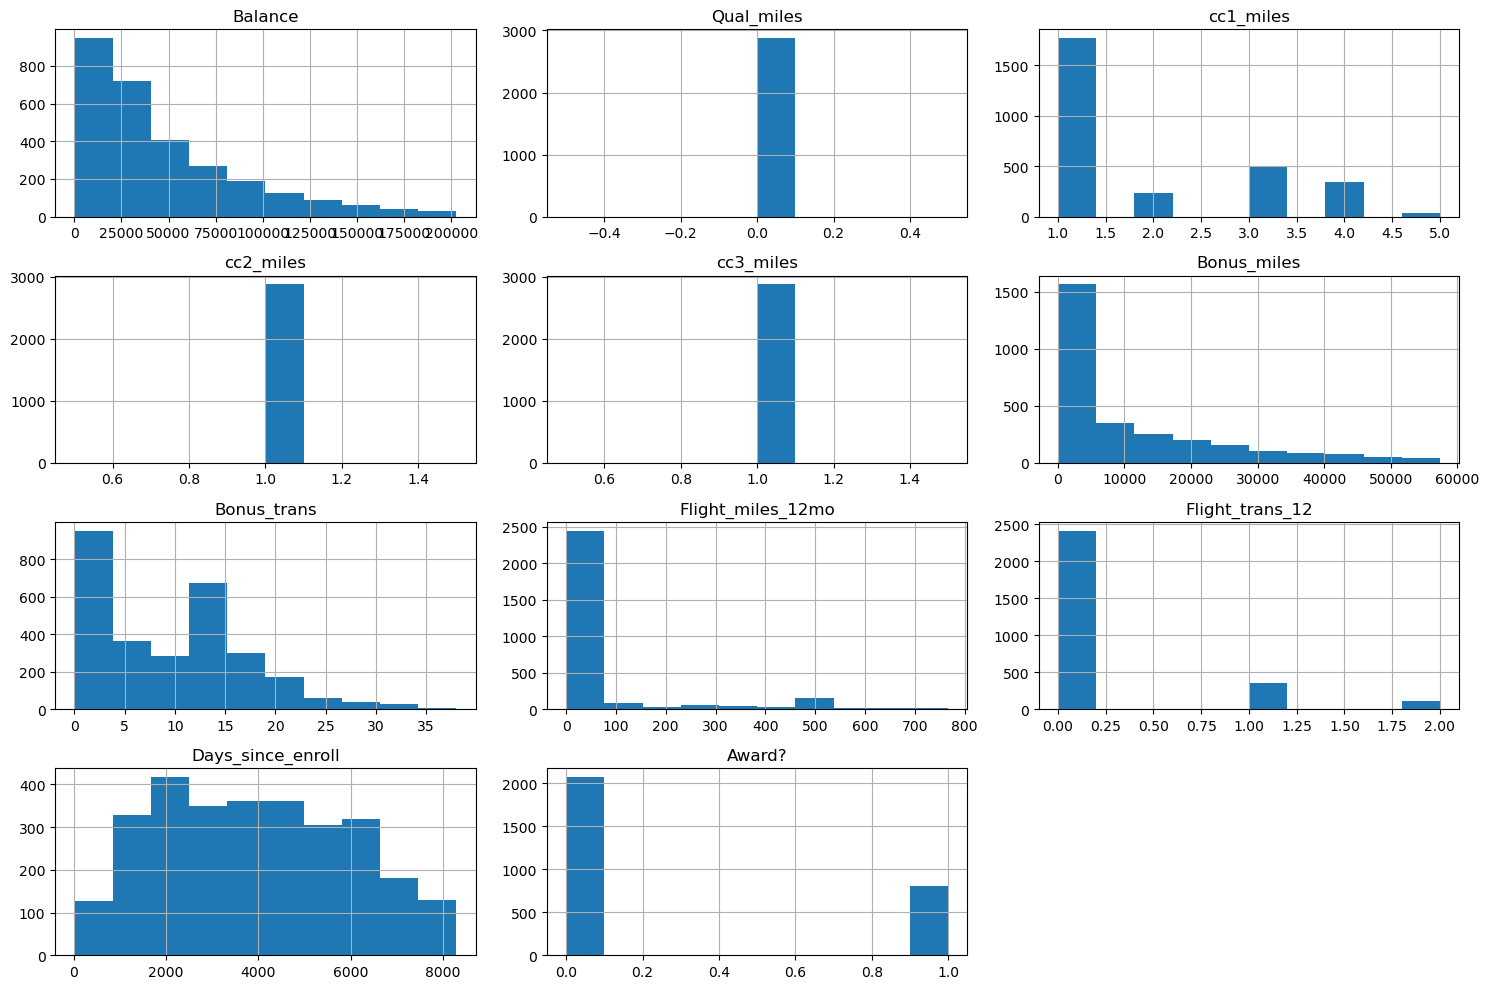

In [8]:
#histogram
df1.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

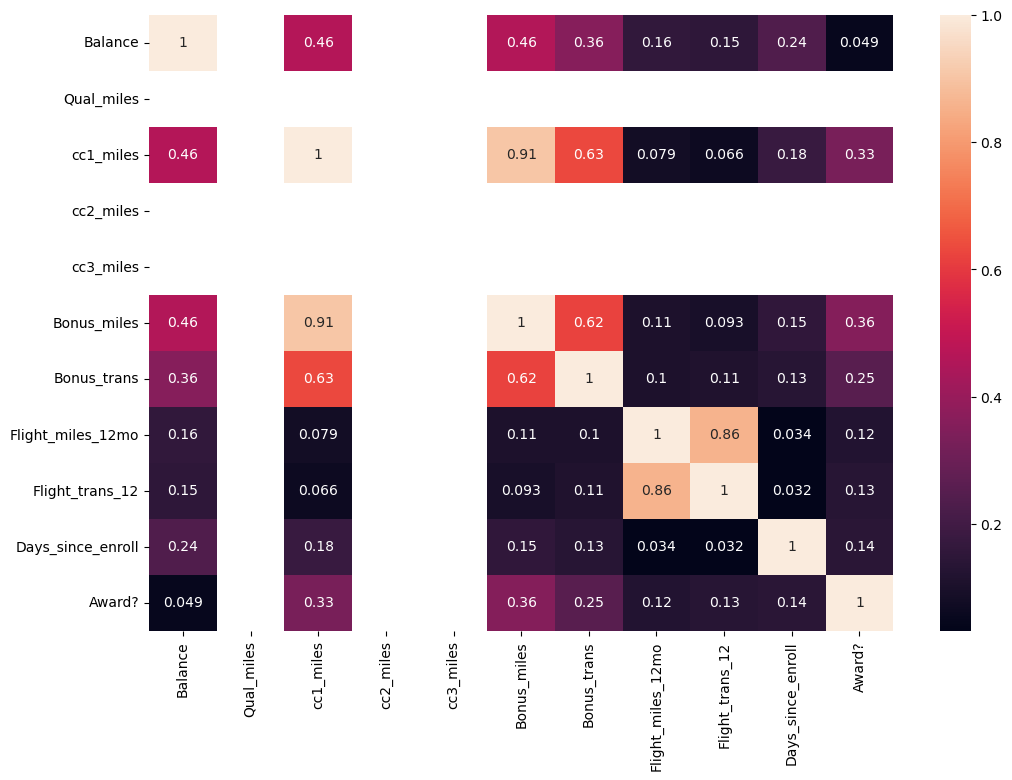

In [9]:
#correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df1.corr(), annot=True)
plt.show()

In [10]:
#feature scaling
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df1)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df1.columns
)

scaled_df.head()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
0,-0.438859,0.0,-0.719055,0.0,0.0,-0.783131,-1.081732,-0.378837,-0.409708,1.503693,-0.623072
1,-0.647735,0.0,-0.719055,0.0,0.0,-0.780130,-0.952735,-0.378837,-0.409708,1.488035,-0.623072
2,-0.128773,0.0,-0.719055,0.0,0.0,-0.494075,-0.694742,-0.378837,-0.409708,1.520330,-0.623072
3,-0.752607,0.0,-0.719055,0.0,0.0,-0.759268,-1.081732,-0.378837,-0.409708,1.480206,-0.623072
4,-0.714019,0.0,-0.719055,0.0,0.0,-0.795867,-1.210728,-0.378837,-0.409708,1.475312,-0.623072


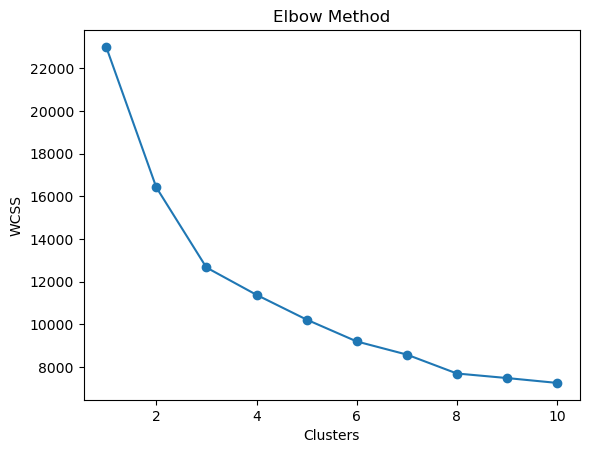

In [11]:
#elbow method
wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        random_state=42
    )
    
    km.fit(scaled_df)
    
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

In [12]:
#k means parameter experiment
for k in range(2,8):

    km = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels = km.fit_predict(scaled_df)

    score = silhouette_score(
        scaled_df,
        labels
    )

    print(
        "K =", k,
        "Score =", score
    )

K = 2 Score = 0.32241400527279074
K = 3 Score = 0.34184773367504273
K = 4 Score = 0.22962827467448732
K = 5 Score = 0.24173542157075825
K = 6 Score = 0.2553188320125063
K = 7 Score = 0.2569959214101372


In [14]:
# k- means model
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(scaled_df)

df1["KMeans_Cluster"] = kmeans_labels

In [15]:
#k-means cluster count
df1["KMeans_Cluster"].value_counts()

KMeans_Cluster
1    962
3    789
2    771
0    353
Name: count, dtype: int64

In [16]:
#k-means silhoutte score
score = silhouette_score(
    scaled_df,
    kmeans_labels
)

print(score)

0.22962827467448732


In [17]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = kmeans_labels

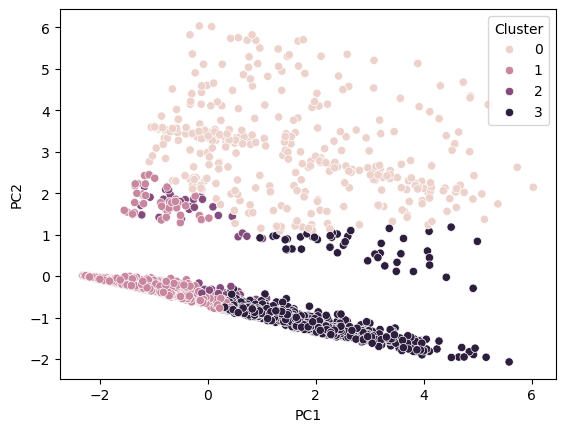

In [18]:
#k-means visualization
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="Cluster",
    data=pca_df
)

plt.show()

In [19]:
#k-means cluster analysis
df1.groupby(
    "KMeans_Cluster"
).mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?
KMeans_Cluster,,,,,,,,,,,
0,65113.991501,0.0,2.065156,1.0,1.0,14463.011331,11.756374,428.084986,1.308782,4098.711048,0.447592
1,25552.377339,0.0,1.092516,1.0,1.0,2772.070686,5.465696,4.810811,0.038462,2068.735967,0.107069
2,36146.795071,0.0,1.138781,1.0,1.0,3479.610895,6.156939,4.203632,0.036316,5642.370947,0.206226
3,75069.773131,0.0,3.299113,1.0,1.0,26368.466413,16.259823,6.510773,0.055767,4439.508238,0.486692


In [20]:
#DBSCAN parameter experiment
eps_values = [0.5,1.0,1.5,2.0]

for eps in eps_values:

    db = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = db.fit_predict(scaled_df)

    n_clusters = len(set(labels)) - (
        1 if -1 in labels else 0
    )

    print(
        "EPS =", eps,
        "Clusters =", n_clusters
    )

EPS = 0.5 Clusters = 19
EPS = 1.0 Clusters = 14
EPS = 1.5 Clusters = 7
EPS = 2.0 Clusters = 7


In [21]:
#apply dbscan
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(
    scaled_df
)

df1["DBSCAN_Cluster"] = db_labels

In [22]:
#DBSCAN cluster count
df1["DBSCAN_Cluster"].value_counts()

DBSCAN_Cluster
 0    1805
 2     602
 3     180
 1     124
-1     115
 4      37
 5       7
 6       5
Name: count, dtype: int64

In [23]:
#DBSCAN Silhoutte score
if len(set(db_labels)) > 1:

    score = silhouette_score(
        scaled_df,
        db_labels
    )

    print(score)

else:
    print("Only one cluster found")

0.24853704856341488


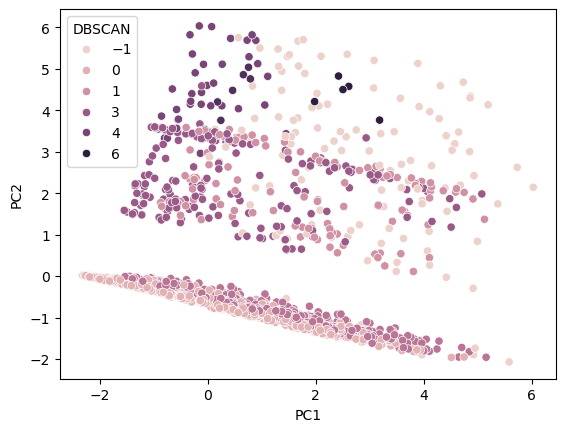

In [24]:
#DBSCAN Visualization
pca_df["DBSCAN"] = db_labels

sns.scatterplot(
    x="PC1",
    y="PC2",
    hue="DBSCAN",
    data=pca_df
)

plt.show()

In [25]:
#DBSCAN Cluster analysis
df1.groupby(
    "DBSCAN_Cluster"
).mean()

,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll,Award?,KMeans_Cluster
DBSCAN_Cluster,,,,,,,,,,,,
-1,103574.400000,0.0,2.626087,1.0,1.0,21837.817391,17.382609,368.356522,1.469565,4901.565217,0.617391,0.643478
0,42801.730194,0.0,1.567867,1.0,1.0,7473.067590,7.873684,0.000000,0.000000,3717.924100,0.000000,1.755679
1,41631.967742,0.0,2.411290,1.0,1.0,19086.629032,11.838710,338.854839,1.000000,4091.209677,1.000000,0.491935
2,46506.757475,0.0,2.431894,1.0,1.0,18152.727575,12.192691,0.000000,0.000000,4391.569767,1.000000,2.423588
3,57542.688889,0.0,1.694444,1.0,1.0,9664.983333,9.205556,322.661111,1.000000,3885.416667,0.000000,0.600000
4,39179.270270,0.0,1.027027,1.0,1.0,2568.972973,5.270270,433.486486,2.000000,3613.297297,0.000000,0.000000
5,24826.714286,0.0,1.000000,1.0,1.0,3270.857143,6.142857,396.142857,2.000000,2555.428571,1.000000,0.000000
6,71428.200000,0.0,3.200000,1.0,1.0,21422.000000,14.000000,570.000000,2.000000,2697.200000,0.000000,0.000000


In [26]:
Conclusion:

1. Data preprocessing was performed including outlier removal and scaling.
2. EDA and visualizations were used to understand data distribution.
3. K-Means clustering was implemented and optimal K was selected using Elbow Method.
4. DBSCAN clustering was implemented using different eps values.
5. Clusters were visualized using PCA scatter plots.
6. Silhouette Score was used for evaluating both algorithms.
7. K-Means produced well-defined customer segments while DBSCAN identified dense regions and noise points.
DBSCAN Insights:

Cluster -1:
Represents noise or outlier customers.

Other Clusters:
Represent dense groups of customers with similar travel behavior.


SyntaxError: invalid syntax (3313395708.py, line 1)